In [6]:
%pip install wfdb

Python(87324) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install torch torchvision

Python(87325) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install seaborn

Python(87326) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install scikit-learn

Python(87327) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install tqdm

Python(87328) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


=== PTB-XL Dataset Analysis ===

1. Loading Data...
Dataset shape: (21799, 27)
Number of patients: 18869
Date range: 1984-11-09 09:17:34 to 2001-06-11 16:43:01

2. Loading Raw Signals...
Signal data shape: (21799, 1000, 12)
Signal length: 1000 samples at 100Hz = 10.0 seconds
Number of leads: 12

=== 3. DEMOGRAPHIC ANALYSIS ===


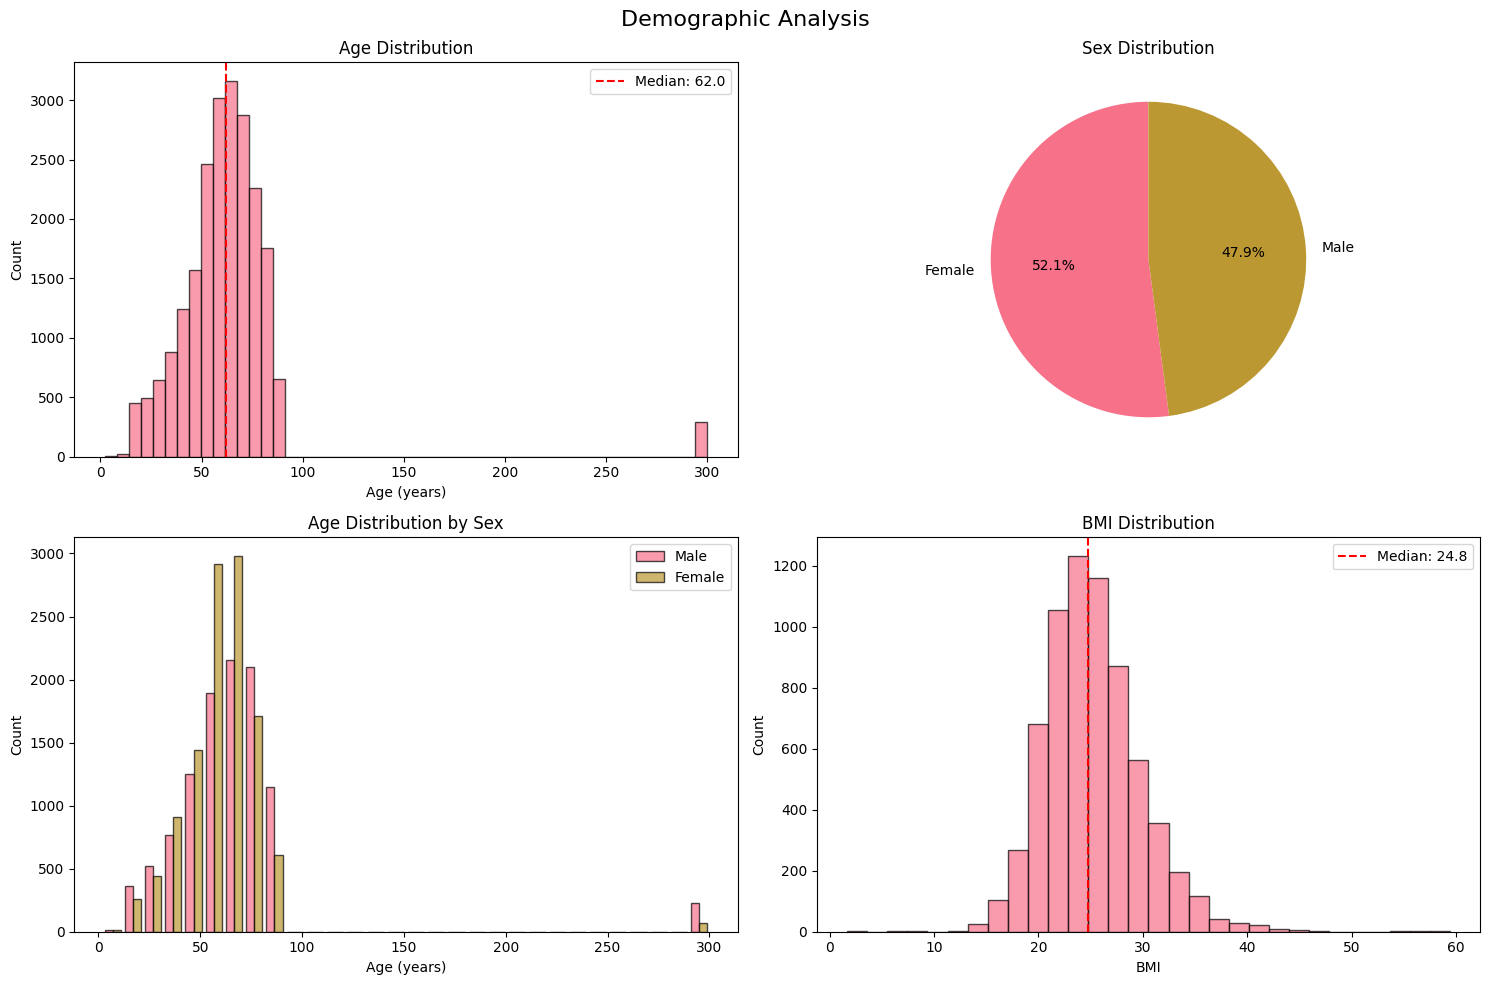

Age statistics:
count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

Sex distribution:
sex
0    11354
1    10445
Name: count, dtype: int64

BMI statistics (available for 6748 records):
count    6748.000000
mean       25.215091
std         4.648292
min         1.670620
25%        22.074100
50%        24.772097
75%        27.741359
max        59.416025
Name: bmi, dtype: float64

=== 4. DIAGNOSTIC ANALYSIS ===
Diagnostic superclass distribution:
NORM: 9514 (43.6%)
MI: 5469 (25.1%)
STTC: 5235 (24.0%)
CD: 4898 (22.5%)
HYP: 2649 (12.2%)


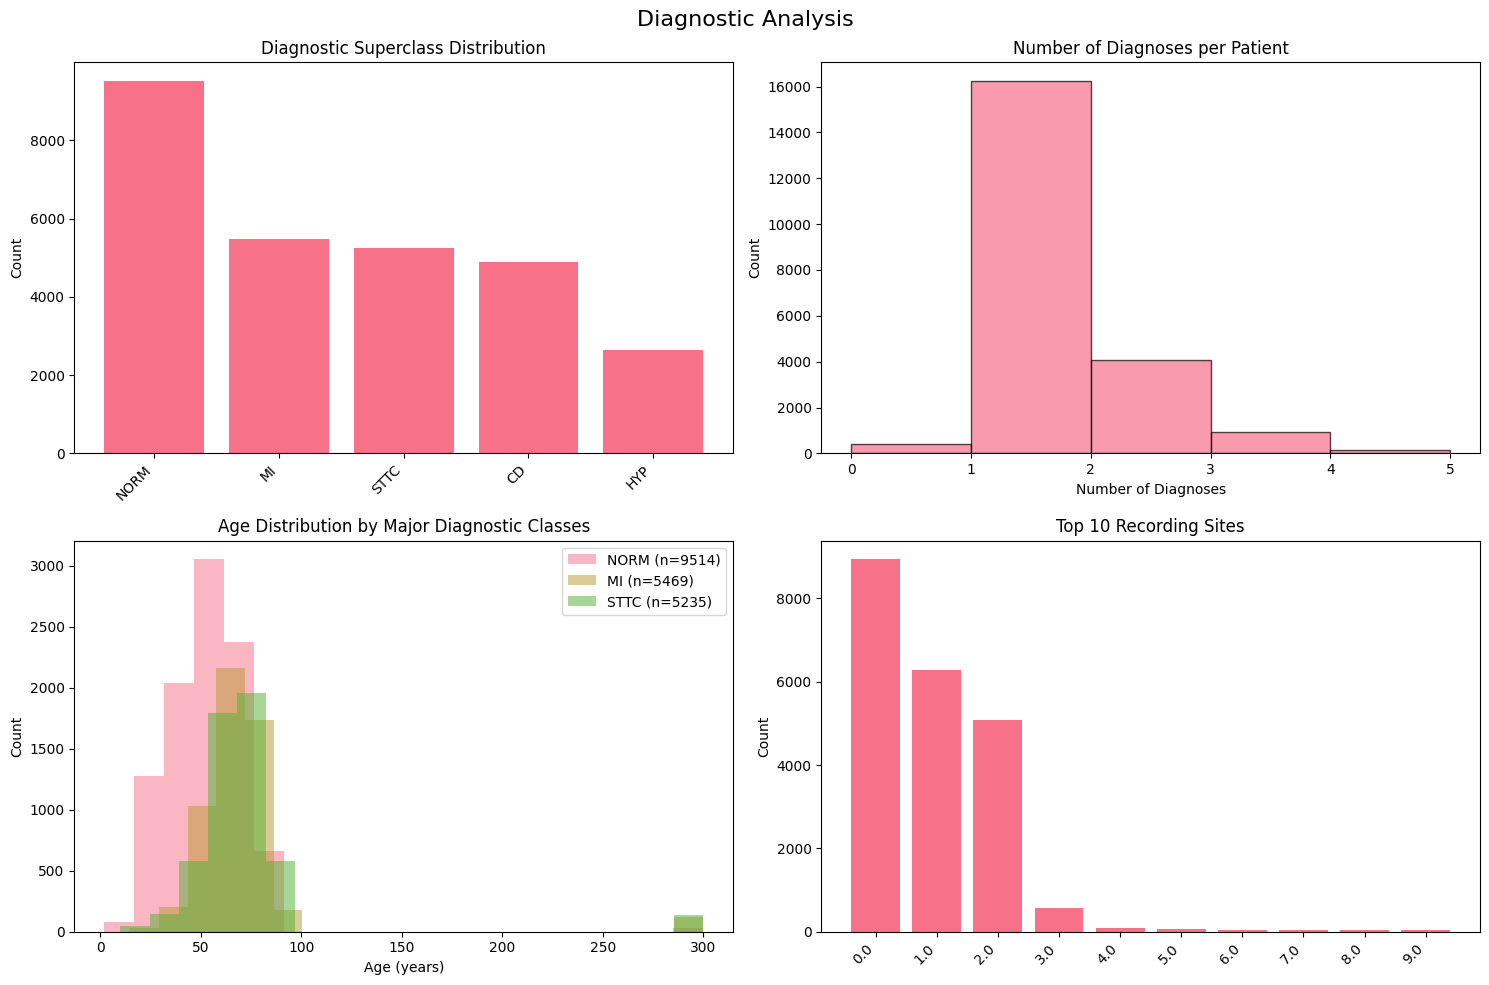


=== 5. SIGNAL QUALITY ANALYSIS ===


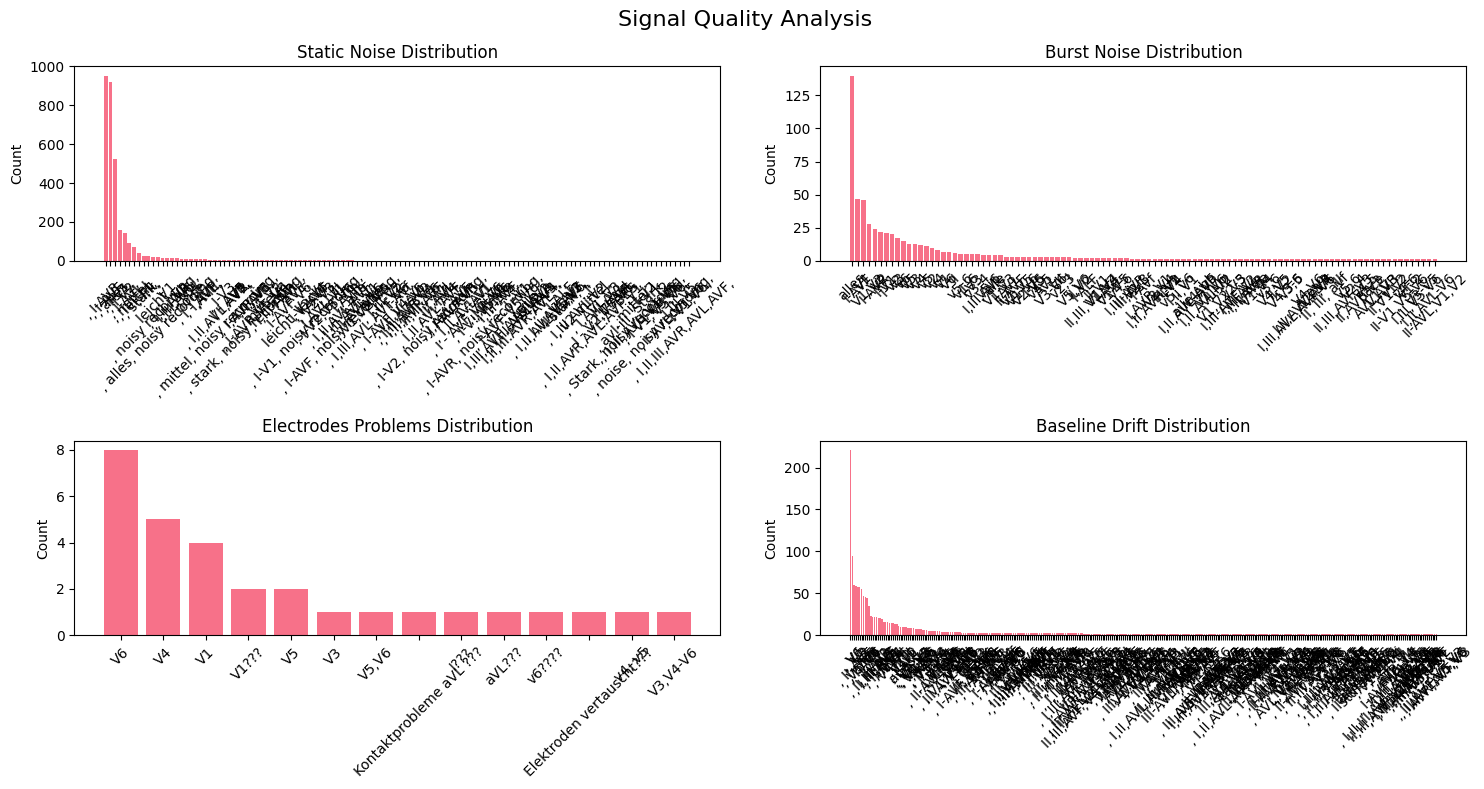

Signal quality statistics:

static_noise:
static_noise
, I-AVR,      953
, I-AVF,      919
, alles,      522
, I-V1,       156
, I-V2,       144
Name: count, dtype: int64

burst_noise:
burst_noise
alles    140
I-AVF     47
V1        46
V1,V2     28
I-AVR     24
Name: count, dtype: int64

electrodes_problems:
electrodes_problems
V6       8
V4       5
V1       4
V1???    2
V5       2
Name: count, dtype: int64

baseline_drift:
baseline_drift
, V6        221
, V1         94
, II-AVF     60
, V3         59
, V2         58
Name: count, dtype: int64

=== 6. ECG SIGNAL ANALYSIS ===
Signal characteristics:
- Shape: (21799, 1000, 12)
- Data type: float64
- Value range: [-20.032, 17.212]
- Mean: -0.001
- Standard deviation: 0.235


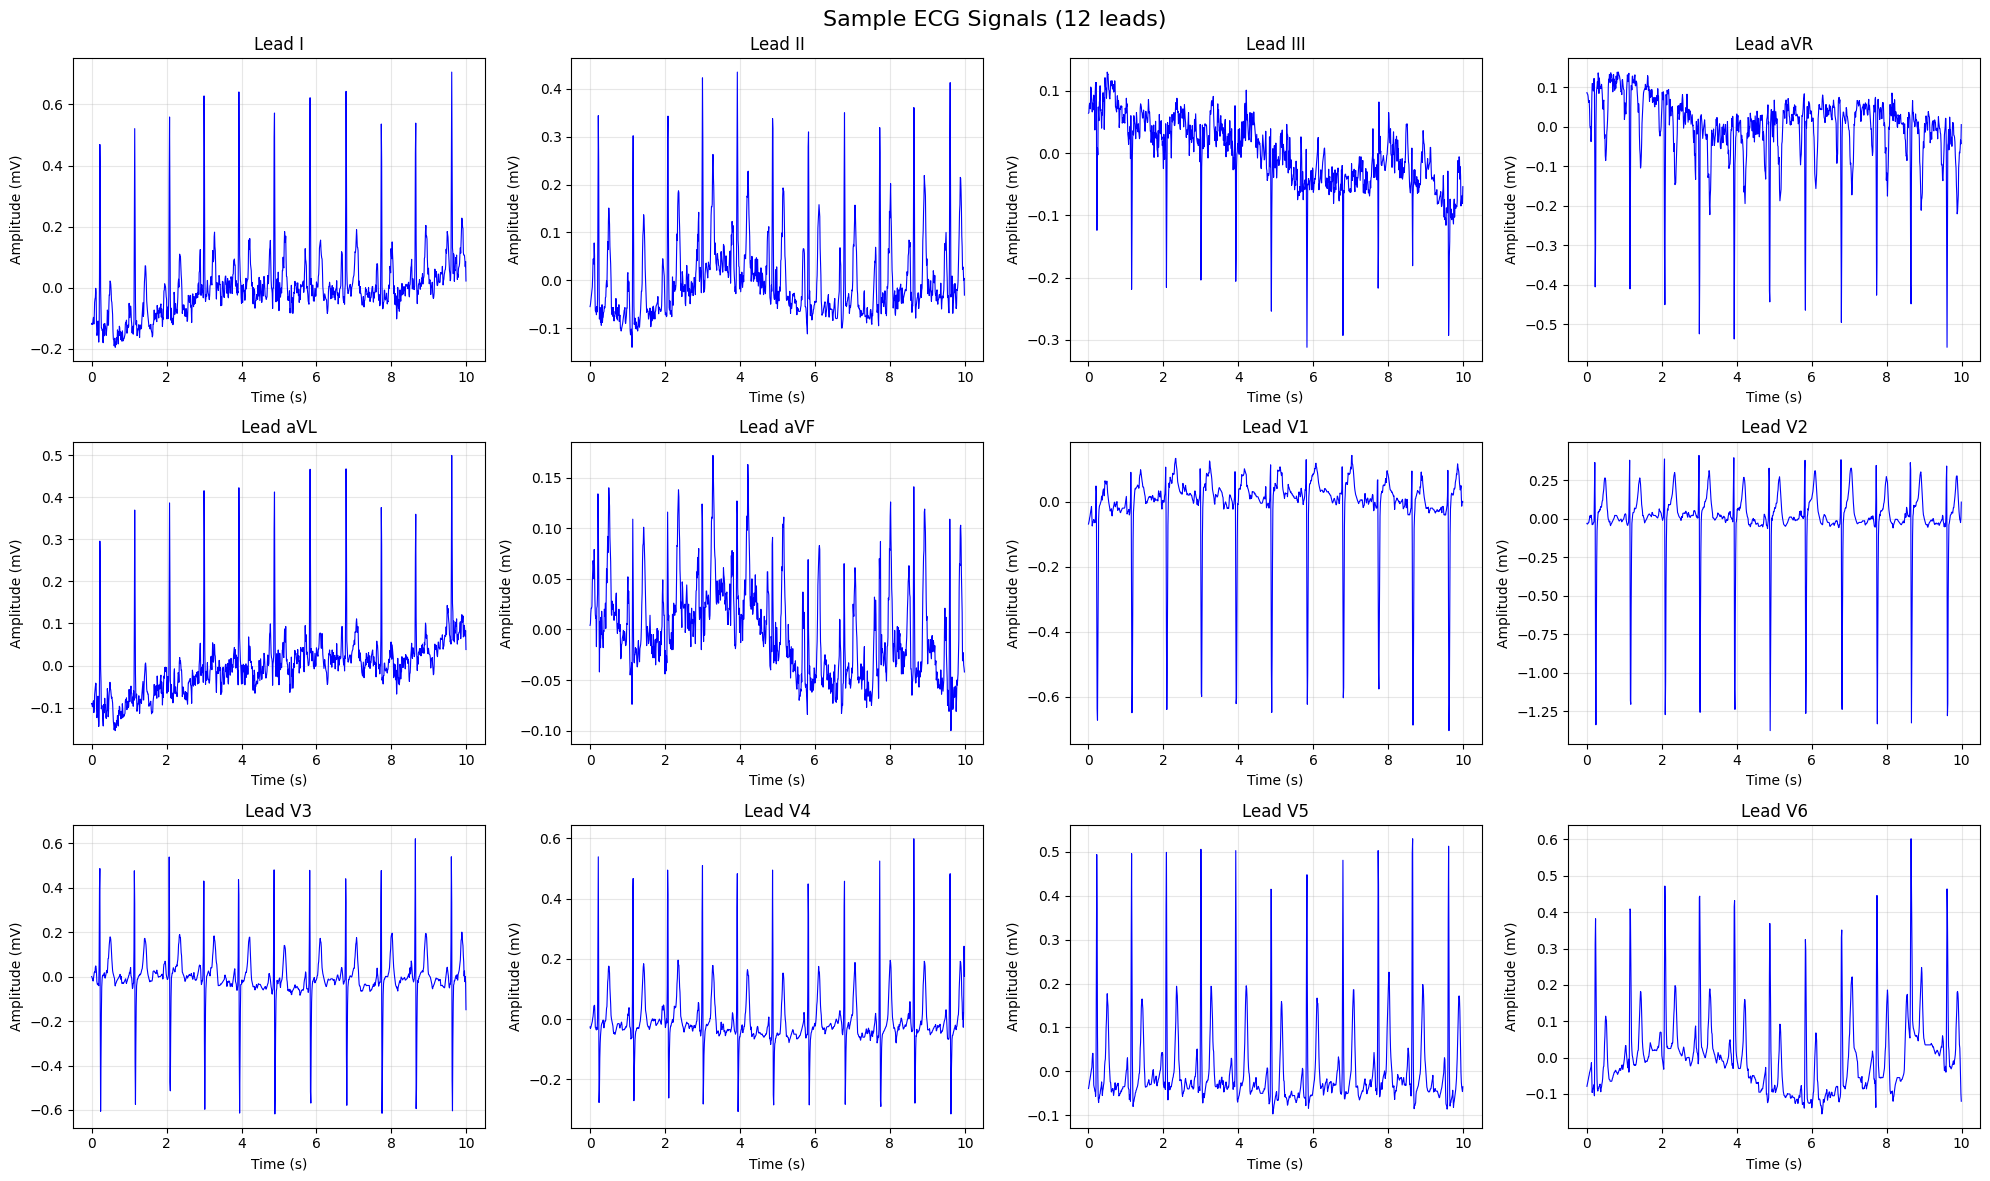


=== 7. MULTI-MODAL FEATURES SUMMARY ===
Available features for multi-modal analysis:
Demographics: ['age', 'sex', 'height', 'weight', 'bmi']
Signal Quality: ['static_noise', 'burst_noise', 'baseline_drift']
Recording Context: ['site', 'device', 'recording_date']
Clinical Context: ['heart_axis', 'validated_by_human']

Feature completeness:
age: 100.0% complete (21799/21799 records)
sex: 100.0% complete (21799/21799 records)
height: 32.0% complete (6974/21799 records)
weight: 43.2% complete (9421/21799 records)
bmi: 31.0% complete (6748/21799 records)
static_noise: 15.0% complete (3260/21799 records)
burst_noise: 2.8% complete (613/21799 records)
baseline_drift: 7.3% complete (1598/21799 records)
site: 99.9% complete (21782/21799 records)
device: 100.0% complete (21799/21799 records)
recording_date: 100.0% complete (21799/21799 records)
heart_axis: 61.2% complete (13331/21799 records)
validated_by_human: 100.0% complete (21799/21799 records)

=== 8. TRAIN/TEST SPLIT ANALYSIS ===
Trainin

In [1]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

def load_raw_data(df, sampling_rate, path):
    """Load raw ECG signal data"""
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

# Configuration
sampling_rate = 100
path = '/Users/bhuvan/Documents/BA878/project/'

print("=== PTB-XL Dataset Analysis ===")
print("\n1. Loading Data...")

# Load main database
Y = pd.read_csv('ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load statement mappings
agg_df = pd.read_csv('scp_statements.csv', index_col=0)
diagnostic_agg_df = agg_df[agg_df.diagnostic == 1]

print(f"Dataset shape: {Y.shape}")
print(f"Number of patients: {Y.patient_id.nunique()}")
print(f"Date range: {Y.recording_date.min()} to {Y.recording_date.max()}")

# Load raw signal data (this might take a while)
print("\n2. Loading Raw Signals...")
X = load_raw_data(Y, sampling_rate, path)
print(f"Signal data shape: {X.shape}")
print(f"Signal length: {X.shape[1]} samples at {sampling_rate}Hz = {X.shape[1]/sampling_rate:.1f} seconds")
print(f"Number of leads: {X.shape[2]}")

# Create diagnostic aggregations
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in diagnostic_agg_df.index:
            tmp.append(diagnostic_agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

def aggregate_all_scp(y_dic, agg_df):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(key)
    return tmp

# Apply aggregations
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)
Y['all_scp_codes'] = Y.scp_codes.apply(lambda x: list(x.keys()))

print("\n=== 3. DEMOGRAPHIC ANALYSIS ===")

# Age analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Demographic Analysis', fontsize=16)

# Age distribution
axes[0,0].hist(Y.age, bins=50, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(Y.age.median(), color='red', linestyle='--', label=f'Median: {Y.age.median():.1f}')
axes[0,0].legend()

# Sex distribution
sex_counts = Y.sex.value_counts()
axes[0,1].pie(sex_counts.values, labels=['Male' if x==1 else 'Female' for x in sex_counts.index], 
              autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Sex Distribution')

# Age by sex
Y_clean_age = Y.dropna(subset=['age', 'sex'])
ages_male = Y_clean_age[Y_clean_age.sex == 1].age
ages_female = Y_clean_age[Y_clean_age.sex == 0].age
axes[1,0].hist([ages_male, ages_female], bins=30, alpha=0.7, 
               label=['Male', 'Female'], edgecolor='black')
axes[1,0].set_title('Age Distribution by Sex')
axes[1,0].set_xlabel('Age (years)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# BMI analysis (if available)
Y['bmi'] = Y.weight / (Y.height/100)**2
valid_bmi = Y.dropna(subset=['bmi'])
if len(valid_bmi) > 0:
    axes[1,1].hist(valid_bmi.bmi, bins=30, alpha=0.7, edgecolor='black')
    axes[1,1].set_title('BMI Distribution')
    axes[1,1].set_xlabel('BMI')
    axes[1,1].set_ylabel('Count')
    axes[1,1].axvline(valid_bmi.bmi.median(), color='red', linestyle='--', 
                      label=f'Median: {valid_bmi.bmi.median():.1f}')
    axes[1,1].legend()
else:
    axes[1,1].text(0.5, 0.5, 'BMI data not available', ha='center', va='center')
    axes[1,1].set_title('BMI Distribution')

plt.tight_layout()
plt.show()

# Print demographic statistics
print(f"Age statistics:")
print(Y.age.describe())
print(f"\nSex distribution:")
print(Y.sex.value_counts())
print(f"\nBMI statistics (available for {len(valid_bmi)} records):")
if len(valid_bmi) > 0:
    print(valid_bmi.bmi.describe())

print("\n=== 4. DIAGNOSTIC ANALYSIS ===")

# Diagnostic superclass analysis
all_superclasses = []
for classes in Y.diagnostic_superclass:
    all_superclasses.extend(classes)

superclass_counts = Counter(all_superclasses)
print("Diagnostic superclass distribution:")
for class_name, count in superclass_counts.most_common():
    print(f"{class_name}: {count} ({count/len(Y)*100:.1f}%)")

# Plot diagnostic distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Diagnostic Analysis', fontsize=16)

# Superclass distribution
classes, counts = zip(*superclass_counts.most_common())
axes[0,0].bar(range(len(classes)), counts)
axes[0,0].set_xticks(range(len(classes)))
axes[0,0].set_xticklabels(classes, rotation=45, ha='right')
axes[0,0].set_title('Diagnostic Superclass Distribution')
axes[0,0].set_ylabel('Count')

# Number of diagnoses per patient
num_diagnoses = [len(classes) for classes in Y.diagnostic_superclass]
axes[0,1].hist(num_diagnoses, bins=range(max(num_diagnoses)+2), alpha=0.7, edgecolor='black')
axes[0,1].set_title('Number of Diagnoses per Patient')
axes[0,1].set_xlabel('Number of Diagnoses')
axes[0,1].set_ylabel('Count')

# Age distribution by major diagnostic class
major_classes = [class_name for class_name, count in superclass_counts.most_common(3)]
for i, diag_class in enumerate(major_classes):
    ages_with_diag = []
    for idx, classes in enumerate(Y.diagnostic_superclass):
        if diag_class in classes and pd.notna(Y.iloc[idx].age):
            ages_with_diag.append(Y.iloc[idx].age)
    
    if len(ages_with_diag) > 0:
        axes[1,0].hist(ages_with_diag, bins=20, alpha=0.5, 
                       label=f'{diag_class} (n={len(ages_with_diag)})')

axes[1,0].set_title('Age Distribution by Major Diagnostic Classes')
axes[1,0].set_xlabel('Age (years)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Recording site analysis
site_counts = Y.site.value_counts().head(10)
axes[1,1].bar(range(len(site_counts)), site_counts.values)
axes[1,1].set_xticks(range(len(site_counts)))
axes[1,1].set_xticklabels(site_counts.index, rotation=45, ha='right')
axes[1,1].set_title('Top 10 Recording Sites')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n=== 5. SIGNAL QUALITY ANALYSIS ===")

# Signal quality metrics
quality_columns = ['static_noise', 'burst_noise', 'electrodes_problems', 'baseline_drift']
available_quality = [col for col in quality_columns if col in Y.columns]

if available_quality:
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    fig.suptitle('Signal Quality Analysis', fontsize=16)
    
    for i, col in enumerate(available_quality[:4]):
        row, col_idx = i//2, i%2
        if Y[col].dtype in ['int64', 'float64']:
            # Numeric quality metric
            axes[row, col_idx].hist(Y[col].dropna(), bins=20, alpha=0.7, edgecolor='black')
            axes[row, col_idx].set_title(f'{col.replace("_", " ").title()} Distribution')
            axes[row, col_idx].set_ylabel('Count')
        else:
            # Categorical quality metric
            value_counts = Y[col].value_counts()
            axes[row, col_idx].bar(range(len(value_counts)), value_counts.values)
            axes[row, col_idx].set_xticks(range(len(value_counts)))
            axes[row, col_idx].set_xticklabels(value_counts.index, rotation=45)
            axes[row, col_idx].set_title(f'{col.replace("_", " ").title()} Distribution')
            axes[row, col_idx].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Print quality statistics
    print("Signal quality statistics:")
    for col in available_quality:
        print(f"\n{col}:")
        if Y[col].dtype in ['int64', 'float64']:
            print(Y[col].describe())
        else:
            print(Y[col].value_counts().head())

print("\n=== 6. ECG SIGNAL ANALYSIS ===")

# Analyze signal characteristics
print(f"Signal characteristics:")
print(f"- Shape: {X.shape}")
print(f"- Data type: {X.dtype}")
print(f"- Value range: [{X.min():.3f}, {X.max():.3f}]")
print(f"- Mean: {X.mean():.3f}")
print(f"- Standard deviation: {X.std():.3f}")

# Plot sample ECG signals
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Sample ECG Signals (12 leads)', fontsize=16)

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Plot first ECG as example
sample_idx = 0
time_axis = np.arange(X.shape[1]) / sampling_rate

for lead in range(12):
    row, col = lead//4, lead%4
    axes[row, col].plot(time_axis, X[sample_idx, :, lead], 'b-', linewidth=0.8)
    axes[row, col].set_title(f'Lead {lead_names[lead]}')
    axes[row, col].set_xlabel('Time (s)')
    axes[row, col].set_ylabel('Amplitude (mV)')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== 7. MULTI-MODAL FEATURES SUMMARY ===")

# Identify available features for multi-modal analysis
demographic_features = ['age', 'sex', 'height', 'weight', 'bmi']
quality_features = available_quality
recording_features = ['site', 'device', 'recording_date']
clinical_features = ['heart_axis', 'validated_by_human']

available_demographic = [f for f in demographic_features if f in Y.columns and Y[f].notna().sum() > 100]
available_quality = [f for f in quality_features if f in Y.columns and Y[f].notna().sum() > 100]
available_recording = [f for f in recording_features if f in Y.columns and Y[f].notna().sum() > 100]
available_clinical = [f for f in clinical_features if f in Y.columns and Y[f].notna().sum() > 100]

print("Available features for multi-modal analysis:")
print(f"Demographics: {available_demographic}")
print(f"Signal Quality: {available_quality}")
print(f"Recording Context: {available_recording}")
print(f"Clinical Context: {available_clinical}")

# Feature completeness analysis
print(f"\nFeature completeness:")
for feature in available_demographic + available_quality + available_recording + available_clinical:
    if feature in Y.columns:
        completeness = Y[feature].notna().sum() / len(Y) * 100
        print(f"{feature}: {completeness:.1f}% complete ({Y[feature].notna().sum()}/{len(Y)} records)")

print("\n=== 8. TRAIN/TEST SPLIT ANALYSIS ===")

# Analyze the provided train/test splits
test_fold = 10
train_mask = Y.strat_fold != test_fold
test_mask = Y.strat_fold == test_fold

print(f"Training set: {train_mask.sum()} records ({train_mask.sum()/len(Y)*100:.1f}%)")
print(f"Test set: {test_mask.sum()} records ({test_mask.sum()/len(Y)*100:.1f}%)")

# Check distribution balance
train_Y = Y[train_mask]
test_Y = Y[test_mask]

print(f"\nAge distribution balance:")
print(f"Train age: {train_Y.age.mean():.1f} ± {train_Y.age.std():.1f}")
print(f"Test age: {test_Y.age.mean():.1f} ± {test_Y.age.std():.1f}")

print(f"\nSex distribution balance:")
print(f"Train male %: {(train_Y.sex == 1).mean()*100:.1f}%")
print(f"Test male %: {(test_Y.sex == 1).mean()*100:.1f}%")

# Check diagnostic balance
train_superclasses = []
test_superclasses = []
for classes in train_Y.diagnostic_superclass:
    train_superclasses.extend(classes)
for classes in test_Y.diagnostic_superclass:
    test_superclasses.extend(classes)

train_counts = Counter(train_superclasses)
test_counts = Counter(test_superclasses)

print(f"\nDiagnostic class balance:")
for class_name in superclass_counts.keys():
    train_pct = train_counts.get(class_name, 0) / len(train_Y) * 100
    test_pct = test_counts.get(class_name, 0) / len(test_Y) * 100
    print(f"{class_name}: Train {train_pct:.1f}%, Test {test_pct:.1f}%")

print("\n=== ANALYSIS COMPLETE ===")
print("Next steps for multi-modal modeling:")
print("1. Preprocess and encode categorical features")
print("2. Handle missing values in metadata")
print("3. Design fusion architecture for signals + metadata")
print("4. Compare against signal-only baseline")

In [13]:
Y.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass,all_scp_codes,bmi
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM],"[NORM, LVOLT, SR]",NaN
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM],"[NORM, SBRAD]",NaN
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],"[NORM, SR]",NaN
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM],"[NORM, SR]",NaN
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM],"[NORM, SR]",NaN


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import pickle

class MultiModalPreprocessor:
    """
    Preprocessing pipeline for multi-modal ECG data
    Handles: ECG signals + demographics + signal quality + recording context
    """
    
    def __init__(self):
        self.scalers = {}
        self.encoders = {}
        self.imputers = {}
        self.feature_names = {}
        
    def prepare_labels(self, Y, label_type='superclass'):
        """
        Prepare diagnostic labels for multi-label classification
        
        Args:
            Y: DataFrame with diagnostic information
            label_type: 'superclass', 'subclass', or 'all'
        
        Returns:
            Binary label matrix (n_samples, n_classes)
        """
        from sklearn.preprocessing import MultiLabelBinarizer
        
        if label_type == 'superclass':
            labels = Y['diagnostic_superclass'].values
        else:
            labels = Y['all_scp_codes'].values
            
        mlb = MultiLabelBinarizer()
        y_binary = mlb.fit_transform(labels)
        
        print(f"Label shape: {y_binary.shape}")
        print(f"Number of classes: {len(mlb.classes_)}")
        print(f"Classes: {mlb.classes_}")
        
        self.label_encoder = mlb
        return y_binary
    
    def prepare_demographic_features(self, Y, fit=True):
        """
        Prepare demographic features: age, sex, height, weight, BMI
        """
        features = []
        feature_names = []
        
        # Age (continuous)
        if 'age' in Y.columns:
            age = Y['age'].values.reshape(-1, 1)
            if fit:
                self.imputers['age'] = SimpleImputer(strategy='median')
                self.scalers['age'] = StandardScaler()
                age = self.imputers['age'].fit_transform(age)
                age = self.scalers['age'].fit_transform(age)
            else:
                age = self.imputers['age'].transform(age)
                age = self.scalers['age'].transform(age)
            features.append(age)
            feature_names.append('age_scaled')
        
        # Sex (binary)
        if 'sex' in Y.columns:
            sex = Y['sex'].fillna(Y['sex'].mode()[0]).values.reshape(-1, 1)
            features.append(sex)
            feature_names.append('sex')
        
        # Height (continuous)
        if 'height' in Y.columns:
            height = Y['height'].values.reshape(-1, 1)
            if fit:
                self.imputers['height'] = SimpleImputer(strategy='median')
                self.scalers['height'] = StandardScaler()
                height = self.imputers['height'].fit_transform(height)
                height = self.scalers['height'].fit_transform(height)
            else:
                height = self.imputers['height'].transform(height)
                height = self.scalers['height'].transform(height)
            features.append(height)
            feature_names.append('height_scaled')
        
        # Weight (continuous)
        if 'weight' in Y.columns:
            weight = Y['weight'].values.reshape(-1, 1)
            if fit:
                self.imputers['weight'] = SimpleImputer(strategy='median')
                self.scalers['weight'] = StandardScaler()
                weight = self.imputers['weight'].fit_transform(weight)
                weight = self.scalers['weight'].fit_transform(weight)
            else:
                weight = self.imputers['weight'].transform(weight)
                weight = self.scalers['weight'].transform(weight)
            features.append(weight)
            feature_names.append('weight_scaled')
        
        # BMI (derived)
        if 'height' in Y.columns and 'weight' in Y.columns:
            bmi = Y['weight'] / (Y['height']/100)**2
            bmi = bmi.values.reshape(-1, 1)
            if fit:
                self.imputers['bmi'] = SimpleImputer(strategy='median')
                self.scalers['bmi'] = StandardScaler()
                bmi = self.imputers['bmi'].fit_transform(bmi)
                bmi = self.scalers['bmi'].fit_transform(bmi)
            else:
                bmi = self.imputers['bmi'].transform(bmi)
                bmi = self.scalers['bmi'].transform(bmi)
            features.append(bmi)
            feature_names.append('bmi_scaled')
        
        if fit:
            self.feature_names['demographic'] = feature_names
        
        demographic_features = np.hstack(features) if features else np.array([]).reshape(len(Y), 0)
        print(f"Demographic features shape: {demographic_features.shape}")
        return demographic_features
    
    def prepare_signal_quality_features(self, Y, fit=True):
        """
        Prepare signal quality features - handles both numeric and categorical data
        """
        features = []
        feature_names = []
        
        quality_cols = ['static_noise', 'burst_noise', 'baseline_drift', 'electrodes_problems']
        
        for col in quality_cols:
            if col in Y.columns:
                # Check if column is numeric or contains numeric values
                try:
                    # Try to convert to numeric, coercing errors to NaN
                    vals_numeric = pd.to_numeric(Y[col], errors='coerce').values.reshape(-1, 1)
                    
                    # If mostly numeric, treat as continuous
                    if np.isnan(vals_numeric).sum() < len(vals_numeric) * 0.5:
                        if fit:
                            self.imputers[col] = SimpleImputer(strategy='median')
                            self.scalers[col] = StandardScaler()
                            vals = self.imputers[col].fit_transform(vals_numeric)
                            vals = self.scalers[col].fit_transform(vals)
                        else:
                            vals = self.imputers[col].transform(vals_numeric)
                            vals = self.scalers[col].transform(vals)
                        features.append(vals)
                        feature_names.append(f'{col}_scaled')
                    else:
                        # If mostly non-numeric, encode as binary (present/absent)
                        vals_binary = (~Y[col].isna()).astype(int).values.reshape(-1, 1)
                        features.append(vals_binary)
                        feature_names.append(f'{col}_present')
                        
                except Exception as e:
                    # If any error, treat as binary indicator
                    print(f"Warning: Could not process {col} as numeric, treating as binary indicator")
                    vals_binary = (~Y[col].isna()).astype(int).values.reshape(-1, 1)
                    features.append(vals_binary)
                    feature_names.append(f'{col}_present')
        
        if fit:
            self.feature_names['quality'] = feature_names
        
        quality_features = np.hstack(features) if features else np.array([]).reshape(len(Y), 0)
        print(f"Signal quality features shape: {quality_features.shape}")
        return quality_features
    
    def prepare_recording_context_features(self, Y, fit=True):
        """
        Prepare recording context: site, device
        Handles missing values and unseen categories
        """
        features = []
        feature_names = []
        
        # Recording site (categorical - one-hot encode)
        if 'site' in Y.columns:
            site_filled = Y['site'].fillna('unknown').astype(str)
            
            if fit:
                self.encoders['site'] = LabelEncoder()
                site_encoded = self.encoders['site'].fit_transform(site_filled)
                n_sites = len(self.encoders['site'].classes_)
            else:
                # Handle unseen categories in test set
                site_encoded = np.zeros(len(site_filled), dtype=int)
                for idx, val in enumerate(site_filled):
                    if val in self.encoders['site'].classes_:
                        site_encoded[idx] = self.encoders['site'].transform([val])[0]
                    else:
                        # Assign to 'unknown' if it exists, otherwise to first class
                        if 'unknown' in self.encoders['site'].classes_:
                            site_encoded[idx] = self.encoders['site'].transform(['unknown'])[0]
                        else:
                            site_encoded[idx] = 0
                n_sites = len(self.encoders['site'].classes_)
            
            # One-hot encode
            site_onehot = np.eye(n_sites)[site_encoded]
            features.append(site_onehot)
            
            if fit:
                feature_names.extend([f'site_{i}' for i in range(n_sites)])
        
        # Device (categorical)
        if 'device' in Y.columns:
            device_filled = Y['device'].fillna('unknown').astype(str)
            
            if fit:
                self.encoders['device'] = LabelEncoder()
                device_encoded = self.encoders['device'].fit_transform(device_filled)
                n_devices = len(self.encoders['device'].classes_)
            else:
                # Handle unseen categories in test set
                device_encoded = np.zeros(len(device_filled), dtype=int)
                for idx, val in enumerate(device_filled):
                    if val in self.encoders['device'].classes_:
                        device_encoded[idx] = self.encoders['device'].transform([val])[0]
                    else:
                        if 'unknown' in self.encoders['device'].classes_:
                            device_encoded[idx] = self.encoders['device'].transform(['unknown'])[0]
                        else:
                            device_encoded[idx] = 0
                n_devices = len(self.encoders['device'].classes_)
            
            device_onehot = np.eye(n_devices)[device_encoded]
            features.append(device_onehot)
            
            if fit:
                feature_names.extend([f'device_{i}' for i in range(n_devices)])
        
        if fit:
            self.feature_names['recording'] = feature_names
        
        recording_features = np.hstack(features) if features else np.array([]).reshape(len(Y), 0)
        print(f"Recording context features shape: {recording_features.shape}")
        return recording_features
    
    def preprocess_ecg_signals(self, X):
        """
        Preprocess ECG signals
        - Normalize per-lead
        - Handle any NaN values
        """
        # Replace any NaN with 0
        X_clean = np.nan_to_num(X, nan=0.0)
        
        # Normalize each lead independently (per sample)
        X_normalized = np.zeros_like(X_clean)
        for i in range(X_clean.shape[0]):  # For each sample
            for j in range(X_clean.shape[2]):  # For each lead
                lead_data = X_clean[i, :, j]
                # Z-score normalization per lead
                mean = lead_data.mean()
                std = lead_data.std()
                if std > 0:
                    X_normalized[i, :, j] = (lead_data - mean) / std
                else:
                    X_normalized[i, :, j] = lead_data - mean
        
        print(f"ECG signals shape: {X_normalized.shape}")
        print(f"ECG value range after normalization: [{X_normalized.min():.3f}, {X_normalized.max():.3f}]")
        return X_normalized
    
    def fit_transform(self, X, Y, label_type='superclass'):
        """
        Fit preprocessors and transform all data
        
        Returns:
            dict with keys: 'signals', 'demographics', 'quality', 'recording', 'labels'
        """
        print("=== Fitting and Transforming Data ===\n")
        
        # Prepare labels
        y_binary = self.prepare_labels(Y, label_type)
        
        # Prepare features
        X_ecg = self.preprocess_ecg_signals(X)
        X_demo = self.prepare_demographic_features(Y, fit=True)
        X_quality = self.prepare_signal_quality_features(Y, fit=True)
        X_recording = self.prepare_recording_context_features(Y, fit=True)
        
        # Combine all metadata features
        metadata_features = [X_demo, X_quality, X_recording]
        X_metadata = np.hstack([f for f in metadata_features if f.shape[1] > 0])
        
        print(f"\nCombined metadata shape: {X_metadata.shape}")
        print(f"Total features: {X_metadata.shape[1]}")
        
        return {
            'signals': X_ecg,
            'metadata': X_metadata,
            'demographics': X_demo,
            'quality': X_quality,
            'recording': X_recording,
            'labels': y_binary
        }
    
    def transform(self, X, Y, label_type='superclass'):
        """
        Transform data using fitted preprocessors (for validation/test sets)
        """
        print("=== Transforming Data (using fitted preprocessors) ===\n")
        
        # Prepare labels
        y_binary = self.prepare_labels(Y, label_type)
        
        # Prepare features
        X_ecg = self.preprocess_ecg_signals(X)
        X_demo = self.prepare_demographic_features(Y, fit=False)
        X_quality = self.prepare_signal_quality_features(Y, fit=False)
        X_recording = self.prepare_recording_context_features(Y, fit=False)
        
        # Combine all metadata features
        metadata_features = [X_demo, X_quality, X_recording]
        X_metadata = np.hstack([f for f in metadata_features if f.shape[1] > 0])
        
        print(f"\nCombined metadata shape: {X_metadata.shape}")
        
        return {
            'signals': X_ecg,
            'metadata': X_metadata,
            'demographics': X_demo,
            'quality': X_quality,
            'recording': X_recording,
            'labels': y_binary
        }
    
    def save(self, filepath):
        """Save preprocessor state"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'scalers': self.scalers,
                'encoders': self.encoders,
                'imputers': self.imputers,
                'feature_names': self.feature_names,
                'label_encoder': self.label_encoder
            }, f)
        print(f"Preprocessor saved to {filepath}")
    
    def load(self, filepath):
        """Load preprocessor state"""
        with open(filepath, 'rb') as f:
            state = pickle.load(f)
            self.scalers = state['scalers']
            self.encoders = state['encoders']
            self.imputers = state['imputers']
            self.feature_names = state['feature_names']
            self.label_encoder = state['label_encoder']
        print(f"Preprocessor loaded from {filepath}")


# Example usage
if __name__ == "__main__":
    # Assuming you have X, Y loaded from previous steps
    
    # Initialize preprocessor
    preprocessor = MultiModalPreprocessor()
    
    # Split data
    test_fold = 10
    train_mask = Y.strat_fold != test_fold
    test_mask = Y.strat_fold == test_fold
    
    # Fit on training data
    train_data = preprocessor.fit_transform(
        X[train_mask], 
        Y[train_mask], 
        label_type='superclass'
    )
    
    # Transform test data
    test_data = preprocessor.transform(
        X[test_mask], 
        Y[test_mask], 
        label_type='superclass'
    )
    
    # Save preprocessor
    preprocessor.save('preprocessor.pkl')
    
    # Access processed data
    X_train_signals = train_data['signals']
    X_train_metadata = train_data['metadata']
    y_train = train_data['labels']
    
    X_test_signals = test_data['signals']
    X_test_metadata = test_data['metadata']
    y_test = test_data['labels']
    
    print("\n=== Ready for Modeling ===")
    print(f"Training: {X_train_signals.shape[0]} samples")
    print(f"Testing: {X_test_signals.shape[0]} samples")
    print(f"Signal shape: {X_train_signals.shape}")
    print(f"Metadata features: {X_train_metadata.shape[1]}")
    print(f"Number of diagnostic classes: {y_train.shape[1]}")

=== Fitting and Transforming Data ===

Label shape: (19601, 5)
Number of classes: 5
Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
ECG signals shape: (19601, 1000, 12)
ECG value range after normalization: [-27.878, 30.434]
Demographic features shape: (19601, 5)
Signal quality features shape: (19601, 4)
Recording context features shape: (19601, 63)

Combined metadata shape: (19601, 72)
Total features: 72
=== Transforming Data (using fitted preprocessors) ===

Label shape: (2198, 5)
Number of classes: 5
Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
ECG signals shape: (2198, 1000, 12)
ECG value range after normalization: [-15.904, 17.027]
Demographic features shape: (2198, 5)
Signal quality features shape: (2198, 4)
Recording context features shape: (2198, 63)

Combined metadata shape: (2198, 72)
Preprocessor saved to preprocessor.pkl

=== Ready for Modeling ===
Training: 19601 samples
Testing: 2198 samples
Signal shape: (19601, 1000, 12)
Metadata features: 72
Number of diagnostic classes: 5


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ECGDataset(Dataset):
    """Custom dataset for multi-modal ECG data"""
    
    def __init__(self, signals, metadata, labels):
        self.signals = torch.FloatTensor(signals)
        self.metadata = torch.FloatTensor(metadata)
        self.labels = torch.FloatTensor(labels)
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        return {
            'signals': self.signals[idx],
            'metadata': self.metadata[idx],
            'labels': self.labels[idx]
        }


class ResBlock1D(nn.Module):
    """1D Residual Block for ECG signal processing"""
    
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, downsample=None):
        super(ResBlock1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                               stride=stride, padding=kernel_size//2, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=1, padding=kernel_size//2, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out


class ECGSignalEncoder(nn.Module):
    """ResNet-based encoder for ECG signals"""
    
    def __init__(self, num_leads=12, signal_length=1000):
        super(ECGSignalEncoder, self).__init__()
        
        # Initial convolution
        self.conv1 = nn.Conv1d(num_leads, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual blocks
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        # Feature dimension
        self.feature_dim = 512
        
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        layers.append(ResBlock1D(in_channels, out_channels, stride=stride, downsample=downsample))
        for _ in range(1, blocks):
            layers.append(ResBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # x shape: (batch, leads, time) = (batch, 12, 1000)
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = x.squeeze(-1)  # Shape: (batch, 512)
        
        return x


class MetadataEncoder(nn.Module):
    """Dense network for clinical metadata"""
    
    def __init__(self, input_dim, hidden_dims=[128, 64]):
        super(MetadataEncoder, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim
        
        self.encoder = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]
        
    def forward(self, x):
        return self.encoder(x)


class AttentionFusion(nn.Module):
    """Attention-based fusion of signal and metadata features"""
    
    def __init__(self, signal_dim, metadata_dim):
        super(AttentionFusion, self).__init__()
        
        self.signal_attention = nn.Sequential(
            nn.Linear(signal_dim, 1),
            nn.Sigmoid()
        )
        
        self.metadata_attention = nn.Sequential(
            nn.Linear(metadata_dim, 1),
            nn.Sigmoid()
        )
        
    def forward(self, signal_features, metadata_features):
        # Compute attention weights
        signal_weight = self.signal_attention(signal_features)
        metadata_weight = self.metadata_attention(metadata_features)
        
        # Normalize weights
        total_weight = signal_weight + metadata_weight
        signal_weight = signal_weight / total_weight
        metadata_weight = metadata_weight / total_weight
        
        # Weighted concatenation
        weighted_signal = signal_features * signal_weight
        weighted_metadata = metadata_features * metadata_weight
        
        fused = torch.cat([weighted_signal, weighted_metadata], dim=1)
        
        return fused, signal_weight, metadata_weight


class MultiModalECGClassifier(nn.Module):
    """
    Complete multi-modal ECG classification model
    Combines ECG signals with clinical metadata
    """
    
    def __init__(self, num_classes, metadata_dim, num_leads=12, signal_length=1000,
                 fusion_type='attention'):
        super(MultiModalECGClassifier, self).__init__()
        
        self.fusion_type = fusion_type
        
        # Signal encoder
        self.signal_encoder = ECGSignalEncoder(num_leads, signal_length)
        
        # Metadata encoder
        self.metadata_encoder = MetadataEncoder(metadata_dim, hidden_dims=[128, 64])
        
        # Fusion module
        if fusion_type == 'attention':
            self.fusion = AttentionFusion(
                self.signal_encoder.feature_dim,
                self.metadata_encoder.feature_dim
            )
            fused_dim = self.signal_encoder.feature_dim + self.metadata_encoder.feature_dim
        elif fusion_type == 'concat':
            fused_dim = self.signal_encoder.feature_dim + self.metadata_encoder.feature_dim
        else:
            raise ValueError(f"Unknown fusion type: {fusion_type}")
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, signals, metadata, return_attention=False):
        # Encode signals
        signal_features = self.signal_encoder(signals)
        
        # Encode metadata
        metadata_features = self.metadata_encoder(metadata)
        
        # Fuse features
        if self.fusion_type == 'attention':
            fused_features, signal_attn, metadata_attn = self.fusion(
                signal_features, metadata_features
            )
        else:  # concat
            fused_features = torch.cat([signal_features, metadata_features], dim=1)
            signal_attn = metadata_attn = None
        
        # Classify
        logits = self.classifier(fused_features)
        
        if return_attention and self.fusion_type == 'attention':
            return logits, signal_attn, metadata_attn
        else:
            return logits


class SignalOnlyClassifier(nn.Module):
    """Baseline: Signal-only classifier (for comparison)"""
    
    def __init__(self, num_classes, num_leads=12, signal_length=1000):
        super(SignalOnlyClassifier, self).__init__()
        
        self.signal_encoder = ECGSignalEncoder(num_leads, signal_length)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.signal_encoder.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, signals):
        features = self.signal_encoder(signals)
        logits = self.classifier(features)
        return logits


# Training utilities
def create_dataloaders(train_data, test_data, batch_size=32):
    """Create PyTorch dataloaders"""
    
    train_dataset = ECGDataset(
        train_data['signals'],
        train_data['metadata'],
        train_data['labels']
    )
    
    test_dataset = ECGDataset(
        test_data['signals'],
        test_data['metadata'],
        test_data['labels']
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return train_loader, test_loader


# Example usage
if __name__ == "__main__":
    # Example dimensions
    num_classes = 5  # For superclass
    metadata_dim = 20  # Depends on your features
    batch_size = 16
    
    # Create sample data
    sample_signals = torch.randn(batch_size, 12, 1000)  # (batch, leads, time)
    sample_metadata = torch.randn(batch_size, metadata_dim)
    
    # Initialize models
    print("=== Multi-modal Model ===")
    multimodal_model = MultiModalECGClassifier(
        num_classes=num_classes,
        metadata_dim=metadata_dim,
        fusion_type='attention'
    )
    
    output, signal_attn, metadata_attn = multimodal_model(
        sample_signals, sample_metadata, return_attention=True
    )
    
    print(f"Output shape: {output.shape}")
    print(f"Signal attention shape: {signal_attn.shape}")
    print(f"Metadata attention shape: {metadata_attn.shape}")
    
    # Count parameters
    total_params = sum(p.numel() for p in multimodal_model.parameters())
    trainable_params = sum(p.numel() for p in multimodal_model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    print("\n=== Signal-only Baseline Model ===")
    baseline_model = SignalOnlyClassifier(num_classes=num_classes)
    baseline_output = baseline_model(sample_signals)
    print(f"Output shape: {baseline_output.shape}")
    
    baseline_params = sum(p.numel() for p in baseline_model.parameters())
    print(f"Total parameters: {baseline_params:,}")

=== Multi-modal Model ===
Output shape: torch.Size([16, 5])
Signal attention shape: torch.Size([16, 1])
Metadata attention shape: torch.Size([16, 1])
Total parameters: 6,451,463
Trainable parameters: 6,451,463

=== Signal-only Baseline Model ===
Output shape: torch.Size([16, 5])
Total parameters: 6,423,173


MULTI-MODAL ECG CLASSIFICATION - COMPLETE PIPELINE

Transposing signal data for CNN input...
Original shape: (19601, 1000, 12)
Transposed shape: (19601, 12, 1000)
Train batches: 613, Test batches: 69

TRAINING MULTI-MODAL MODEL (20 EPOCHS)
Training on device: cpu
Model type: Multi-modal
Total parameters: 6,458,119
--------------------------------------------------------------------------------

Epoch 1/20


Validation: 100%|██████████| 69/69 [01:00<00:00,  1.15it/s]


Train Loss: 0.3756 | Train AUC: 0.8347
Val Loss: 0.3662 | Val AUC: 0.8529
Learning Rate: 0.001000
✓ Saved best model (AUC: 0.8529)

Epoch 2/20


Validation: 100%|██████████| 69/69 [00:59<00:00,  1.16it/s]


Train Loss: 0.3363 | Train AUC: 0.8683
Val Loss: 0.3331 | Val AUC: 0.8767
Learning Rate: 0.001000
✓ Saved best model (AUC: 0.8767)

Epoch 3/20


...

Train Loss: 0.2418 | Train AUC: 0.9366
Val Loss: 0.3058 | Val AUC: 0.9018
Learning Rate: 0.000500

Epoch 20/20


Validation: 100%|██████████| 69/69 [00:52<00:00,  1.31it/s]


Train Loss: 0.2161 | Train AUC: 0.9492
Val Loss: 0.3096 | Val AUC: 0.9006
Learning Rate: 0.000500

Training complete! Best validation AUC: 0.9042

Evaluating Baseline Model...


Evaluating: 100%|██████████| 69/69 [00:53<00:00,  1.28it/s]



EVALUATION RESULTS

Overall Performance:
  Macro AUC: 0.9042
  Micro AUC: 0.9212

Per-Class Performance:
Class      AUC      F1       Accuracy   Support   
------------------------------------------------------------
CD         0.9142   0.7133   0.8881     496       
HYP        0.8227   0.3351   0.8881     262       
MI         0.9170   0.6709   0.8576     550       
NORM       0.9399   0.8498   0.8571     963       
STTC       0.9272   0.7493   0.8822     521       

GENERATING VISUALIZATIONS


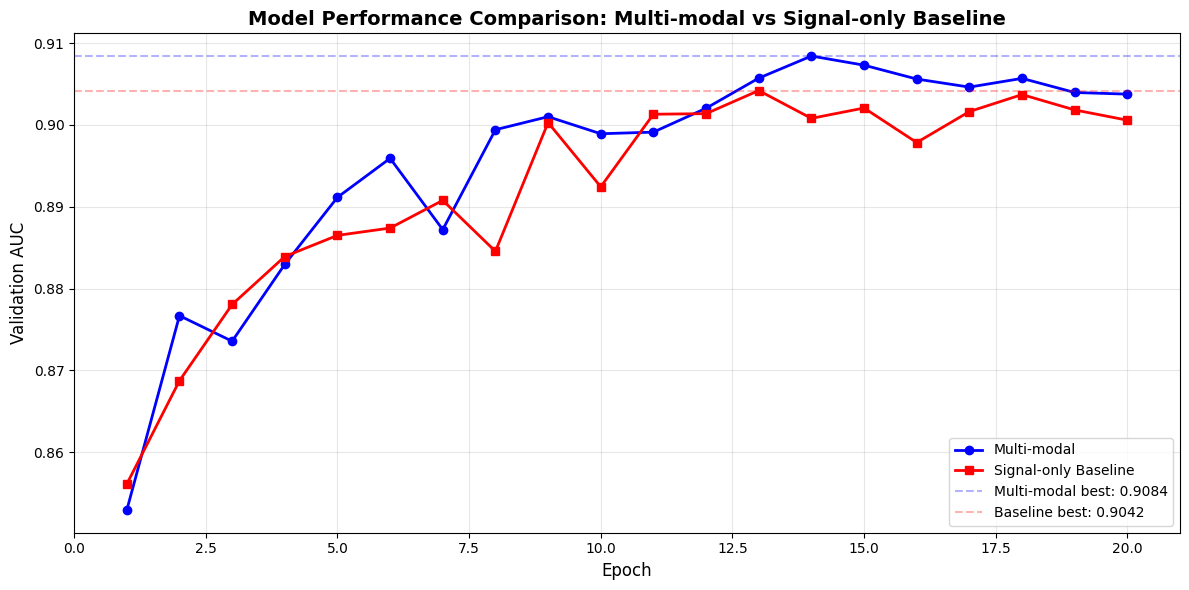

✓ Saved: auc_comparison_by_epoch.png


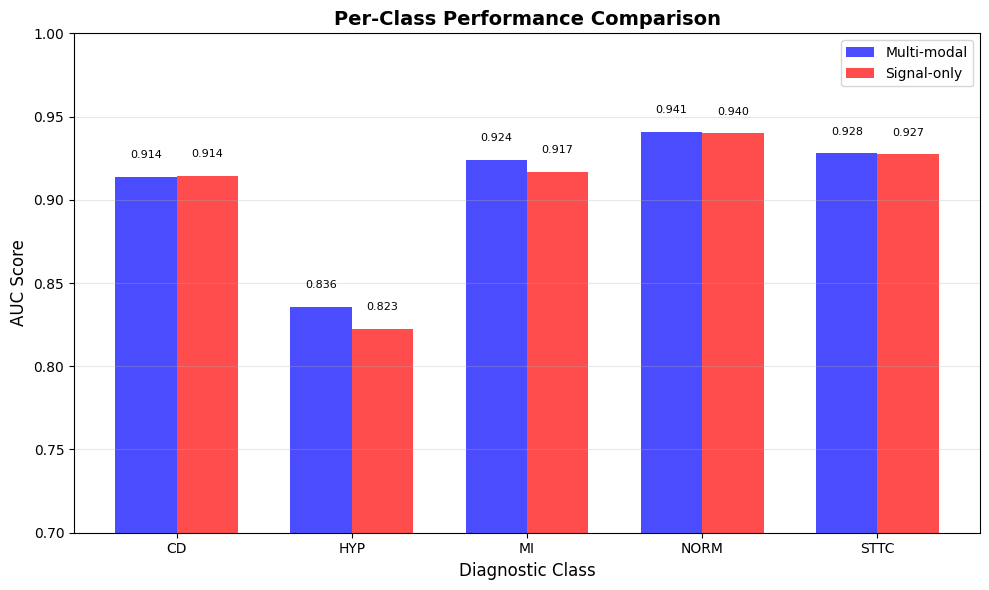

✓ Saved: per_class_comparison.png


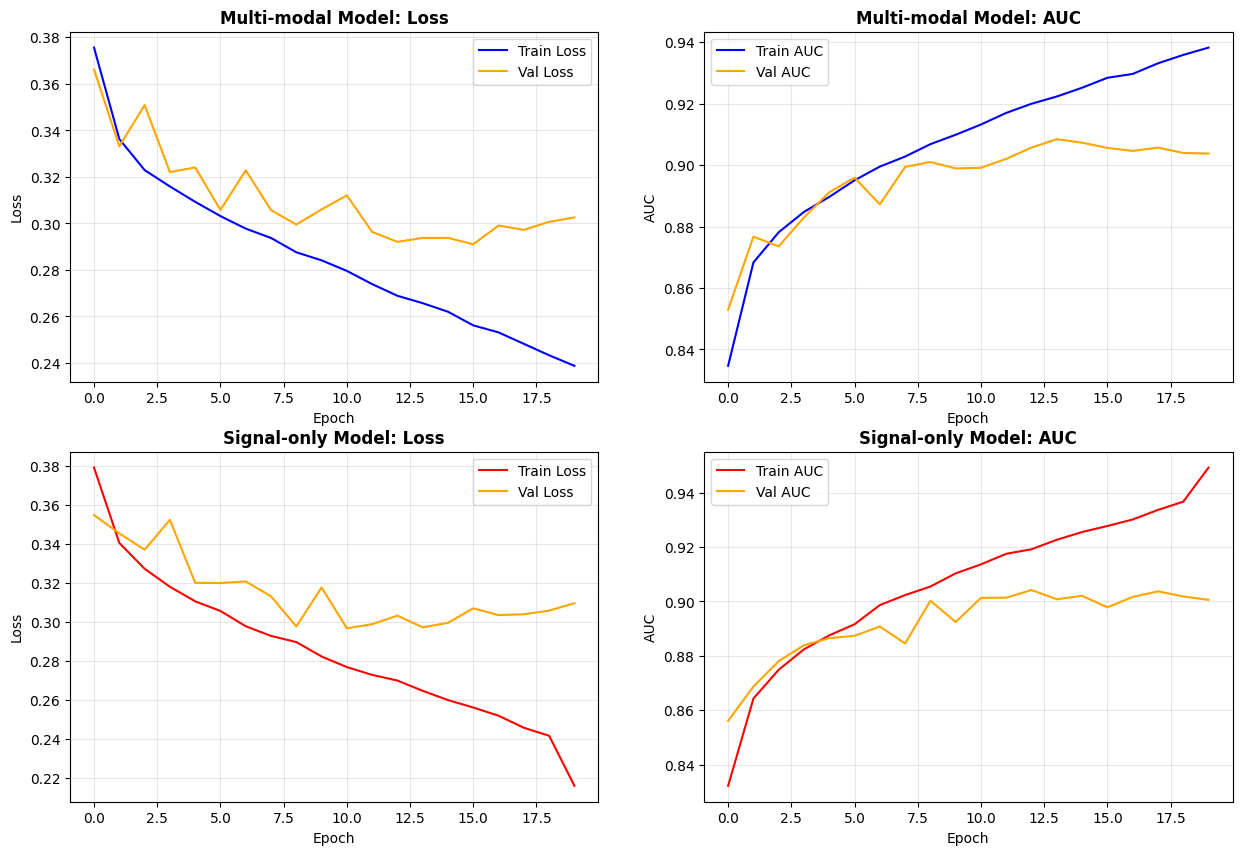

In [3]:
# ============================================================================
# COMPLETE PIPELINE: Models + Training + Evaluation + Visualization
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from tqdm import tqdm

# ============================================================================
# PART 1: Dataset Definition
# ============================================================================

class ECGDataset(Dataset):
    """Custom dataset for multi-modal ECG data"""
    
    def __init__(self, signals, metadata, labels):
        self.signals = torch.FloatTensor(signals)
        self.metadata = torch.FloatTensor(metadata)
        self.labels = torch.FloatTensor(labels)
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        return {
            'signals': self.signals[idx],
            'metadata': self.metadata[idx],
            'labels': self.labels[idx]
        }

# ============================================================================
# PART 2: Model Architectures
# ============================================================================

class ResBlock1D(nn.Module):
    """1D Residual Block for ECG signal processing"""
    
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, downsample=None):
        super(ResBlock1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                               stride=stride, padding=kernel_size//2, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=1, padding=kernel_size//2, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out


class ECGSignalEncoder(nn.Module):
    """ResNet-based encoder for ECG signals"""
    
    def __init__(self, num_leads=12, signal_length=1000):
        super(ECGSignalEncoder, self).__init__()
        
        # Initial convolution
        self.conv1 = nn.Conv1d(num_leads, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual blocks
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        self.feature_dim = 512
        
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        layers.append(ResBlock1D(in_channels, out_channels, stride=stride, downsample=downsample))
        for _ in range(1, blocks):
            layers.append(ResBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = x.squeeze(-1)
        
        return x


class MetadataEncoder(nn.Module):
    """Dense network for clinical metadata"""
    
    def __init__(self, input_dim, hidden_dims=[128, 64]):
        super(MetadataEncoder, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim
        
        self.encoder = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]
        
    def forward(self, x):
        return self.encoder(x)


class AttentionFusion(nn.Module):
    """Attention-based fusion of signal and metadata features"""
    
    def __init__(self, signal_dim, metadata_dim):
        super(AttentionFusion, self).__init__()
        
        self.signal_attention = nn.Sequential(
            nn.Linear(signal_dim, 1),
            nn.Sigmoid()
        )
        
        self.metadata_attention = nn.Sequential(
            nn.Linear(metadata_dim, 1),
            nn.Sigmoid()
        )
        
    def forward(self, signal_features, metadata_features):
        signal_weight = self.signal_attention(signal_features)
        metadata_weight = self.metadata_attention(metadata_features)
        
        total_weight = signal_weight + metadata_weight
        signal_weight = signal_weight / total_weight
        metadata_weight = metadata_weight / total_weight
        
        weighted_signal = signal_features * signal_weight
        weighted_metadata = metadata_features * metadata_weight
        
        fused = torch.cat([weighted_signal, weighted_metadata], dim=1)
        
        return fused, signal_weight, metadata_weight


class MultiModalECGClassifier(nn.Module):
    """Complete multi-modal ECG classification model"""
    
    def __init__(self, num_classes, metadata_dim, num_leads=12, signal_length=1000,
                 fusion_type='attention'):
        super(MultiModalECGClassifier, self).__init__()
        
        self.fusion_type = fusion_type
        
        self.signal_encoder = ECGSignalEncoder(num_leads, signal_length)
        self.metadata_encoder = MetadataEncoder(metadata_dim, hidden_dims=[128, 64])
        
        if fusion_type == 'attention':
            self.fusion = AttentionFusion(
                self.signal_encoder.feature_dim,
                self.metadata_encoder.feature_dim
            )
            fused_dim = self.signal_encoder.feature_dim + self.metadata_encoder.feature_dim
        elif fusion_type == 'concat':
            fused_dim = self.signal_encoder.feature_dim + self.metadata_encoder.feature_dim
        
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, signals, metadata, return_attention=False):
        signal_features = self.signal_encoder(signals)
        metadata_features = self.metadata_encoder(metadata)
        
        if self.fusion_type == 'attention':
            fused_features, signal_attn, metadata_attn = self.fusion(
                signal_features, metadata_features
            )
        else:
            fused_features = torch.cat([signal_features, metadata_features], dim=1)
            signal_attn = metadata_attn = None
        
        logits = self.classifier(fused_features)
        
        if return_attention and self.fusion_type == 'attention':
            return logits, signal_attn, metadata_attn
        else:
            return logits


class SignalOnlyClassifier(nn.Module):
    """Baseline: Signal-only classifier"""
    
    def __init__(self, num_classes, num_leads=12, signal_length=1000):
        super(SignalOnlyClassifier, self).__init__()
        
        self.signal_encoder = ECGSignalEncoder(num_leads, signal_length)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.signal_encoder.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, signals):
        features = self.signal_encoder(signals)
        logits = self.classifier(features)
        return logits

# ============================================================================
# PART 3: Training Class
# ============================================================================

class ECGTrainer:
    """Training pipeline for ECG classification models"""
    
    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.device = device
        self.history = {
            'train_loss': [],
            'train_auc': [],
            'val_loss': [],
            'val_auc': [],
            'learning_rates': []
        }
        
    def train_epoch(self, train_loader, criterion, optimizer, is_multimodal=True):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        all_labels = []
        all_predictions = []
        
        pbar = tqdm(train_loader, desc='Training')
        for batch in pbar:
            signals = batch['signals'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            labels = batch['labels'].to(self.device)
            
            optimizer.zero_grad()
            
            if is_multimodal:
                outputs = self.model(signals, metadata)
            else:
                outputs = self.model(signals)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            all_labels.append(labels.cpu().detach().numpy())
            all_predictions.append(torch.sigmoid(outputs).cpu().detach().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = total_loss / len(train_loader)
        all_labels = np.vstack(all_labels)
        all_predictions = np.vstack(all_predictions)
        
        try:
            auc_scores = []
            for i in range(all_labels.shape[1]):
                if len(np.unique(all_labels[:, i])) > 1:
                    auc = roc_auc_score(all_labels[:, i], all_predictions[:, i])
                    auc_scores.append(auc)
            macro_auc = np.mean(auc_scores) if auc_scores else 0.0
        except:
            macro_auc = 0.0
        
        return avg_loss, macro_auc
    
    def validate(self, val_loader, criterion, is_multimodal=True):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc='Validation'):
                signals = batch['signals'].to(self.device)
                metadata = batch['metadata'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                if is_multimodal:
                    outputs = self.model(signals, metadata)
                else:
                    outputs = self.model(signals)
                
                loss = criterion(outputs, labels)
                
                total_loss += loss.item()
                all_labels.append(labels.cpu().numpy())
                all_predictions.append(torch.sigmoid(outputs).cpu().numpy())
        
        avg_loss = total_loss / len(val_loader)
        all_labels = np.vstack(all_labels)
        all_predictions = np.vstack(all_predictions)
        
        auc_scores = []
        for i in range(all_labels.shape[1]):
            if len(np.unique(all_labels[:, i])) > 1:
                auc = roc_auc_score(all_labels[:, i], all_predictions[:, i])
                auc_scores.append(auc)
        
        macro_auc = np.mean(auc_scores) if auc_scores else 0.0
        
        return avg_loss, macro_auc, all_labels, all_predictions
    
    def train(self, train_loader, val_loader, num_epochs=20, learning_rate=0.001,
              is_multimodal=True, early_stopping_patience=10, save_path='best_model.pth'):
        """Complete training loop"""
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, 
                                                          patience=5)
        
        best_val_auc = 0.0
        patience_counter = 0
        
        print(f"Training on device: {self.device}")
        print(f"Model type: {'Multi-modal' if is_multimodal else 'Signal-only'}")
        print(f"Total parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        print("-" * 80)
        
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            
            train_loss, train_auc = self.train_epoch(train_loader, criterion, optimizer, is_multimodal)
            val_loss, val_auc, _, _ = self.validate(val_loader, criterion, is_multimodal)
            
            scheduler.step(val_auc)
            current_lr = optimizer.param_groups[0]['lr']
            
            self.history['train_loss'].append(train_loss)
            self.history['train_auc'].append(train_auc)
            self.history['val_loss'].append(val_loss)
            self.history['val_auc'].append(val_auc)
            self.history['learning_rates'].append(current_lr)
            
            print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f}")
            print(f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
            print(f"Learning Rate: {current_lr:.6f}")
            
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_auc': val_auc,
                    'history': self.history
                }, save_path)
                print(f"✓ Saved best model (AUC: {val_auc:.4f})")
                patience_counter = 0
            else:
                patience_counter += 1
            
            if patience_counter >= early_stopping_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
        
        print(f"\nTraining complete! Best validation AUC: {best_val_auc:.4f}")
        
        checkpoint = torch.load(save_path, weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        return self.history
    
    def evaluate_detailed(self, test_loader, class_names, is_multimodal=True):
        """Detailed evaluation with per-class metrics"""
        self.model.eval()
        
        all_labels = []
        all_predictions = []
        all_signal_attentions = []
        all_metadata_attentions = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc='Evaluating'):
                signals = batch['signals'].to(self.device)
                metadata = batch['metadata'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                if is_multimodal:
                    outputs, signal_attn, metadata_attn = self.model(
                        signals, metadata, return_attention=True
                    )
                    if signal_attn is not None:
                        all_signal_attentions.append(signal_attn.cpu().numpy())
                        all_metadata_attentions.append(metadata_attn.cpu().numpy())
                else:
                    outputs = self.model(signals)
                
                all_labels.append(labels.cpu().numpy())
                all_predictions.append(torch.sigmoid(outputs).cpu().numpy())
        
        y_true = np.vstack(all_labels)
        y_pred_proba = np.vstack(all_predictions)
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        results = {}
        
        results['macro_auc'] = roc_auc_score(y_true, y_pred_proba, average='macro')
        results['micro_auc'] = roc_auc_score(y_true, y_pred_proba, average='micro')
        
        results['per_class'] = {}
        for i, class_name in enumerate(class_names):
            if len(np.unique(y_true[:, i])) > 1:
                auc = roc_auc_score(y_true[:, i], y_pred_proba[:, i])
                f1 = f1_score(y_true[:, i], y_pred[:, i])
                acc = accuracy_score(y_true[:, i], y_pred[:, i])
                
                results['per_class'][class_name] = {
                    'auc': auc,
                    'f1': f1,
                    'accuracy': acc,
                    'support': y_true[:, i].sum()
                }
        
        if all_signal_attentions:
            signal_attn_all = np.vstack(all_signal_attentions)
            metadata_attn_all = np.vstack(all_metadata_attentions)
            results['attention_stats'] = {
                'signal_mean': signal_attn_all.mean(),
                'signal_std': signal_attn_all.std(),
                'metadata_mean': metadata_attn_all.mean(),
                'metadata_std': metadata_attn_all.std()
            }
        
        return results, y_true, y_pred_proba

def print_evaluation_results(results, class_names):
    """Pretty print evaluation results"""
    print("\n" + "="*80)
    print("EVALUATION RESULTS")
    print("="*80)
    
    print(f"\nOverall Performance:")
    print(f"  Macro AUC: {results['macro_auc']:.4f}")
    print(f"  Micro AUC: {results['micro_auc']:.4f}")
    
    if 'attention_stats' in results:
        print(f"\nAttention Statistics:")
        print(f"  Signal Attention: {results['attention_stats']['signal_mean']:.3f} ± {results['attention_stats']['signal_std']:.3f}")
        print(f"  Metadata Attention: {results['attention_stats']['metadata_mean']:.3f} ± {results['attention_stats']['metadata_std']:.3f}")
    
    print(f"\nPer-Class Performance:")
    print(f"{'Class':<10} {'AUC':<8} {'F1':<8} {'Accuracy':<10} {'Support':<10}")
    print("-" * 60)
    
    for class_name in class_names:
        if class_name in results['per_class']:
            metrics = results['per_class'][class_name]
            print(f"{class_name:<10} {metrics['auc']:<8.4f} {metrics['f1']:<8.4f} "
                  f"{metrics['accuracy']:<10.4f} {int(metrics['support']):<10}")
    
    print("="*80)

# ============================================================================
# PART 4: MAIN EXECUTION SCRIPT
# ============================================================================

print("="*80)
print("MULTI-MODAL ECG CLASSIFICATION - COMPLETE PIPELINE")
print("="*80)

# Configuration
batch_size = 32
num_classes = 5
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Transpose signals for CNN input (batch, leads, time)
print("\nTransposing signal data for CNN input...")
train_signals_transposed = train_data['signals'].transpose(0, 2, 1)
test_signals_transposed = test_data['signals'].transpose(0, 2, 1)

print(f"Original shape: {train_data['signals'].shape}")
print(f"Transposed shape: {train_signals_transposed.shape}")

# Create DataLoaders
train_dataset = ECGDataset(
    train_signals_transposed,
    train_data['metadata'],
    train_data['labels']
)

test_dataset = ECGDataset(
    test_signals_transposed,
    test_data['metadata'],
    test_data['labels']
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

# ============================================================================
# Train Multi-modal Model
# ============================================================================

print("\n" + "="*80)
print("TRAINING MULTI-MODAL MODEL (20 EPOCHS)")
print("="*80)

metadata_dim = train_data['metadata'].shape[1]
multimodal_model = MultiModalECGClassifier(
    num_classes=num_classes,
    metadata_dim=metadata_dim,
    fusion_type='attention'
)

multimodal_trainer = ECGTrainer(multimodal_model)
multimodal_history = multimodal_trainer.train(
    train_loader, test_loader,
    num_epochs=20,
    learning_rate=0.001,
    is_multimodal=True,
    save_path='multimodal_best.pth'
)

print("\nEvaluating Multi-modal Model...")
multimodal_results, _, _ = multimodal_trainer.evaluate_detailed(test_loader, class_names, is_multimodal=True)
print_evaluation_results(multimodal_results, class_names)

# ============================================================================
# Train Baseline Model
# ============================================================================

print("\n" + "="*80)
print("TRAINING BASELINE MODEL (20 EPOCHS)")
print("="*80)

baseline_model = SignalOnlyClassifier(num_classes=num_classes)
baseline_trainer = ECGTrainer(baseline_model)
baseline_history = baseline_trainer.train(
    train_loader, test_loader,
    num_epochs=20,
    learning_rate=0.001,
    is_multimodal=False,
    save_path='baseline_best.pth'
)

print("\nEvaluating Baseline Model...")
baseline_results, _, _ = baseline_trainer.evaluate_detailed(test_loader, class_names, is_multimodal=False)
print_evaluation_results(baseline_results, class_names)

# ============================================================================
# PART 5: VISUALIZATION AND COMPARISON
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Plot 1: AUC Comparison by Epoch
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

epochs = range(1, len(multimodal_history['val_auc']) + 1)
ax.plot(epochs, multimodal_history['val_auc'], 'b-o', label='Multi-modal', linewidth=2, markersize=6)
ax.plot(epochs, baseline_history['val_auc'], 'r-s', label='Signal-only Baseline', linewidth=2, markersize=6)

best_mm_epoch = np.argmax(multimodal_history['val_auc']) + 1
best_mm_auc = max(multimodal_history['val_auc'])
best_bl_epoch = np.argmax(baseline_history['val_auc']) + 1
best_bl_auc = max(baseline_history['val_auc'])

ax.axhline(y=best_mm_auc, color='b', linestyle='--', alpha=0.3, label=f'Multi-modal best: {best_mm_auc:.4f}')
ax.axhline(y=best_bl_auc, color='r', linestyle='--', alpha=0.3, label=f'Baseline best: {best_bl_auc:.4f}')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Model Performance Comparison: Multi-modal vs Signal-only Baseline', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(epochs) + 1)

plt.tight_layout()
plt.savefig('auc_comparison_by_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: auc_comparison_by_epoch.png")

# Plot 2: Per-Class Performance Comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

classes = []
mm_aucs = []
bl_aucs = []

for class_name in class_names:
    if class_name in multimodal_results['per_class'] and class_name in baseline_results['per_class']:
        classes.append(class_name)
        mm_aucs.append(multimodal_results['per_class'][class_name]['auc'])
        bl_aucs.append(baseline_results['per_class'][class_name]['auc'])

x = np.arange(len(classes))
width = 0.35

ax.bar(x - width/2, mm_aucs, width, label='Multi-modal', color='blue', alpha=0.7)
ax.bar(x + width/2, bl_aucs, width, label='Signal-only', color='red', alpha=0.7)

ax.set_xlabel('Diagnostic Class', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Per-Class Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.7, 1.0])

# Add value labels on bars
for i, (mm_auc, bl_auc) in enumerate(zip(mm_aucs, bl_aucs)):
    ax.text(i - width/2, mm_auc + 0.01, f'{mm_auc:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, bl_auc + 0.01, f'{bl_auc:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('per_class_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: per_class_comparison.png")

# Plot 3: Training History (Loss + AUC)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Multi-modal Loss
axes[0, 0].plot(multimodal_history['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(multimodal_history['val_loss'], label='Val Loss', color='orange')
axes[0, 0].set_title('Multi-modal Model: Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Multi-modal AUC
axes[0, 1].plot(multimodal_history['train_auc'], label='Train AUC', color='blue')
axes[0, 1].plot(multimodal_history['val_auc'], label='Val AUC', color='orange')
axes[0, 1].set_title('Multi-modal Model: AUC', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Baseline Loss
axes[1, 0].plot(baseline_history['train_loss'], label='Train Loss', color='red')
axes[1, 0].plot(baseline_history['val_loss'], label='Val Loss', color='orange')
axes[1, 0].set_title('Signal-only Model: Loss', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Baseline AUC
axes[1, 1].plot(baseline_history['train_auc'], label='Train AUC', color='red')
axes[1, 1].plot(baseline_history['val_auc'], label='Val AUC', color='orange')
axes[1, 1].set_title('Signal-only Model: AUC', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
